In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
train_df = pd.read_csv('data/train-test.csv')
val_df = pd.read_csv('data/validation.csv')
dec_df = pd.read_csv('data/december-chart-inputs.csv')

# Parse dates at load: almost every question below is a time question.
for _f in (train_df, val_df, dec_df):
    _f['date'] = pd.to_datetime(_f['date'])

print(f"Train-Test shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"December inputs shape: {dec_df.shape}")
train_df.head()

Train-Test shape: (48000, 14)
Validation shape: (12000, 13)
December inputs shape: (31, 7)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [3]:

print('train    :', list(train_df.columns))
print('validation:', list(val_df.columns))
print('december :', list(dec_df.columns))

_missing_in_dec = sorted(set(train_df.columns) - set(dec_df.columns) - {'posted_rate'})
print('\nIn training but NOT available at December prediction time:')
for c in _missing_in_dec:
    print(f'  - {c}')

print(f'\nquote_signal correlation with posted_rate: '
      f'{train_df.quote_signal.corr(train_df.posted_rate):+.4f}')

train    : ['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']
validation: ['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']
december : ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']

In training but NOT available at December prediction time:
  - delivery_lat
  - delivery_lon
  - load_id
  - market_index
  - pickup_lat
  - pickup_lon
  - quote_signal

quote_signal correlation with posted_rate: -0.0399


**Decision.** `quote_signal` is  absent from the December inputs
entirely, and its correlation with the target is -0.04 

Coordinates and `market_index` are also absent there, but both are
reconstructable: coordinates from a city-name lookup, `market_index` from a
date lookup 

In [4]:
 # Categorical features
cat_cols = ["equipment", "pickup", "delivery"]
cat_cols = [c for c in cat_cols if c in train_df.columns]

num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nCategorical Columns: {cat_cols}")
print(f"Numerical Columns:   {num_cols}")


Categorical Columns: ['equipment', 'pickup', 'delivery']
Numerical Columns:   ['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']


In [5]:
stats = []

for col in num_cols:
    series = train_df[col]
    stats.append({
        "Feature": col,
        "Count": int(series.count()),
        "Missing": int(series.isna().sum()),
        "Missing %": f"{series.isna().mean() * 100:.2f}%",
        "Min": series.min(),
        "Max": series.max(),
        "Mean": series.mean(),
        "Std (SD)": series.std(),
        "Median (50%)": series.median(),
        "Skewness": series.skew(),
    })
display_summary = pd.DataFrame(stats)

for col in ["Min", "Max", "Mean", "Std (SD)", "Median (50%)", "Skewness"]:
    display_summary[col] = display_summary[col].map(lambda x: f"{x:,.4f}" if abs(x) < 10 else f"{x:,.2f}")
print(display_summary.to_string(index=False))

     Feature  Count  Missing Missing %        Min       Max      Mean Std (SD) Median (50%) Skewness
  pickup_lat  48000        0     0.00%      28.36     44.30     35.65   4.3153        35.29   0.1773
  pickup_lon  48000        0     0.00%    -121.70    -69.50    -90.93    13.48       -88.09  -0.6940
delivery_lat  48000        0     0.00%      28.36     44.30     35.64   4.3172        35.29   0.1794
delivery_lon  48000        0     0.00%    -121.70    -69.50    -90.86    13.48       -87.53  -0.6993
    distance  48000        0     0.00%      70.00  3,439.80  1,135.86   728.56       953.30   0.7658
      weight  47700      300     0.62% -47,500.00 47,500.00 31,028.84 9,391.44    31,436.50  -1.9104
market_index  47626      374     0.78%     0.6764    1.4678    1.0834   0.1681       1.0558   0.2143
quote_signal  48000        0     0.00%     0.6923    3.6103    2.0625   0.2914       2.0558   0.1720
 posted_rate  48000        0     0.00%      57.22 25,533.00  2,373.98 1,486.49     2,030.76

1. **`weight` has a minimum of -47,500.** Freight cannot weigh a negative
2. **`posted_rate` has a maximum of 25,533 against a median of 2,031, and a
   skew of 1.90.** The target deserves the same scepticism as the features

Missing  `weight` 0.62%, `market_index` 0.78% - impute or drop

=== Weight Statistical Comparison (Before vs After Sign-Fixing) ===


,Dataset,Total Rows,Non-Null Count,Negative Count,Min,Max,Mean,Std (SD),Median
0,Train: Before Fix (Raw),48000,47700,292,-47500.0,47500.0,31028.84,9391.44,31436.5
1,Train: After Fix (abs()),48000,47700,0,5000.0,47500.0,31417.25,7996.52,31496.0
2,Validation: Before Fix (Raw),12000,11835,145,-47500.0,47500.0,30506.64,10572.59,31193.0
3,Validation: After Fix (abs()),12000,11835,0,5000.0,47500.0,31282.95,7987.94,31332.0


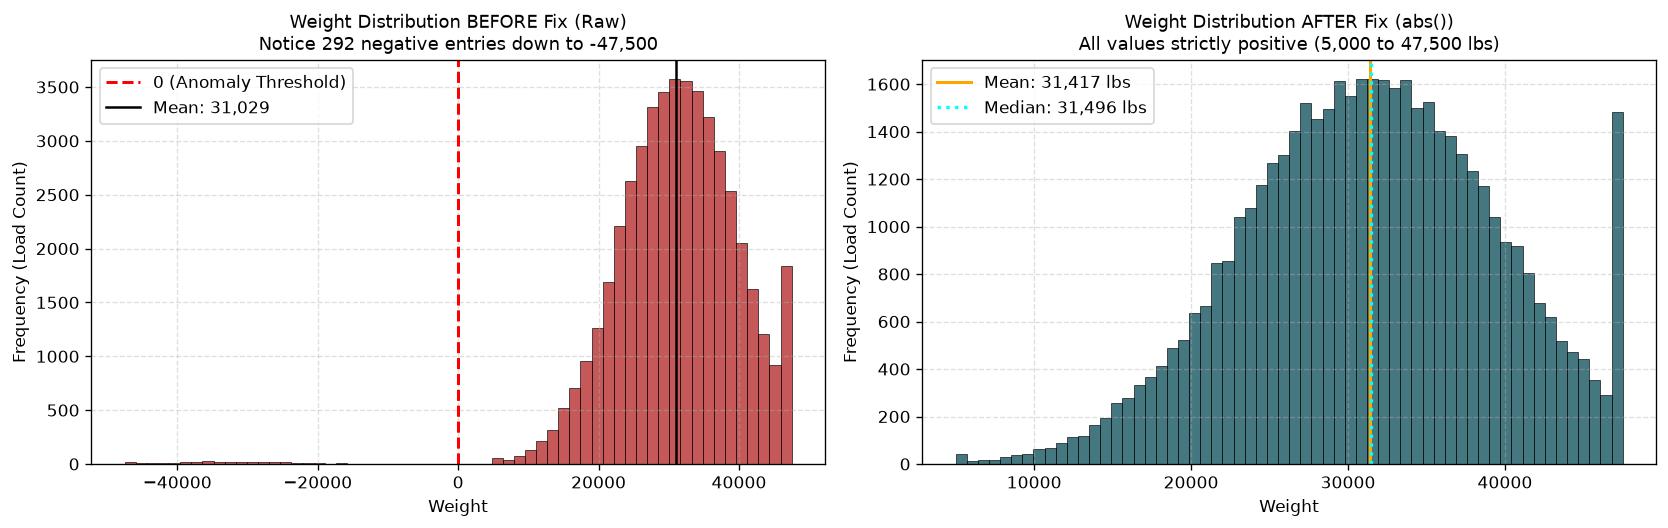

In [20]:
from IPython.display import display
import matplotlib.pyplot as plt

def get_weight_stats(series, label):
    return {
        'Dataset': label,
        'Total Rows': len(series),
        'Non-Null Count': int(series.count()),
        'Negative Count': int((series < 0).sum()),
        'Min': series.min(),
        'Max': series.max(),
        'Mean': round(series.mean(), 2),
        'Std (SD)': round(series.std(), 2),
        'Median': round(series.median(), 2)
    }

weight_comparison_df = pd.DataFrame([
    get_weight_stats(train_df['weight'], 'Train: Before Fix (Raw)'),
    get_weight_stats(train_df['weight'].abs(), 'Train: After Fix (abs())'),
    get_weight_stats(val_df['weight'], 'Validation: Before Fix (Raw)'),
    get_weight_stats(val_df['weight'].abs(), 'Validation: After Fix (abs())')
])

# Apply the fix
train_df['weight_clean'] = train_df['weight'].abs()
val_df['weight_clean'] = val_df['weight'].abs()

# 1. Display comparison table
print('=== Weight Statistical Comparison (Before vs After Sign-Fixing) ===')
display(weight_comparison_df)

# 2. Plot distributions Before vs After
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), dpi=120)

# Before fix (Raw)
axes[0].hist(train_df['weight'].dropna(), bins=60, color='#B22222', alpha=0.75, edgecolor='black', linewidth=0.5)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.8, label='0 (Anomaly Threshold)')
axes[0].axvline(train_df['weight'].mean(), color='black', linestyle='-', linewidth=1.5, label=f"Mean: {train_df['weight'].mean():,.0f}")
axes[0].set_title('Weight Distribution BEFORE Fix (Raw)\nNotice 292 negative entries down to -47,500', fontsize=11)
axes[0].set_xlabel('Weight')
axes[0].set_ylabel('Frequency (Load Count)')
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.4)

# After fix (abs)
axes[1].hist(train_df['weight_clean'].dropna(), bins=60, color='#064A56', alpha=0.75, edgecolor='black', linewidth=0.5)
axes[1].axvline(train_df['weight_clean'].mean(), color='orange', linestyle='-', linewidth=1.8, label=f"Mean: {train_df['weight_clean'].mean():,.0f} lbs")
axes[1].axvline(train_df['weight_clean'].median(), color='cyan', linestyle=':', linewidth=2, label=f"Median: {train_df['weight_clean'].median():,.0f} lbs")
axes[1].set_title('Weight Distribution AFTER Fix (abs())\nAll values strictly positive (5,000 to 47,500 lbs)', fontsize=11)
axes[1].set_xlabel('Weight')
axes[1].set_ylabel('Frequency (Load Count)')
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


**Decision.** magnitude is within range, not an outlier. taking abs() value.

A 25,533 maximum could be one genuine heavy haul, or it could be corruption.
The test: compare each row's posted_rate/distance against the median for its **peer group**
(distance ventile x equipment).

Distribution of $/mile relative to peer-group median:

  [0.00,0.25)     141 
  [0.25,0.50)     196 
  [0.50,0.75)       0    <-- EMPTY GAP
  [0.75,1.00)   23649 ###########################################################
  [1.00,1.25)   23673 ###########################################################
  [1.25,1.50)       1 
  [1.50,1.75)       0    <-- EMPTY GAP
  [1.75,2.00)       0    <-- EMPTY GAP
  [2.00,2.25)       5 
  [2.25,2.50)      34 
  [2.50,2.75)      27 
  [2.75,3.00)      40 
  [3.00,3.25)      41 
  [3.25,3.50)      47 
  [3.50,3.75)      21 
  [3.75,4.00)      16 
  [4.00,4.25)      29 
  [4.25,4.50)      24 
  [4.50,4.75)      26 
  [4.75,5.00)      17 

Flagged 677 rows (1.41%)
Rows in [0.50,0.75): 0
Rows in [1.25,2.00): 1

The distribution is BIMODAL with genuinely empty gaps, so this is
injected corruption, not a heavy tail -- the cut point is insensitive
anywhere inside the gap.

Spread evenly across months (~67/month), confirming injection:
date
2025-01    81
20

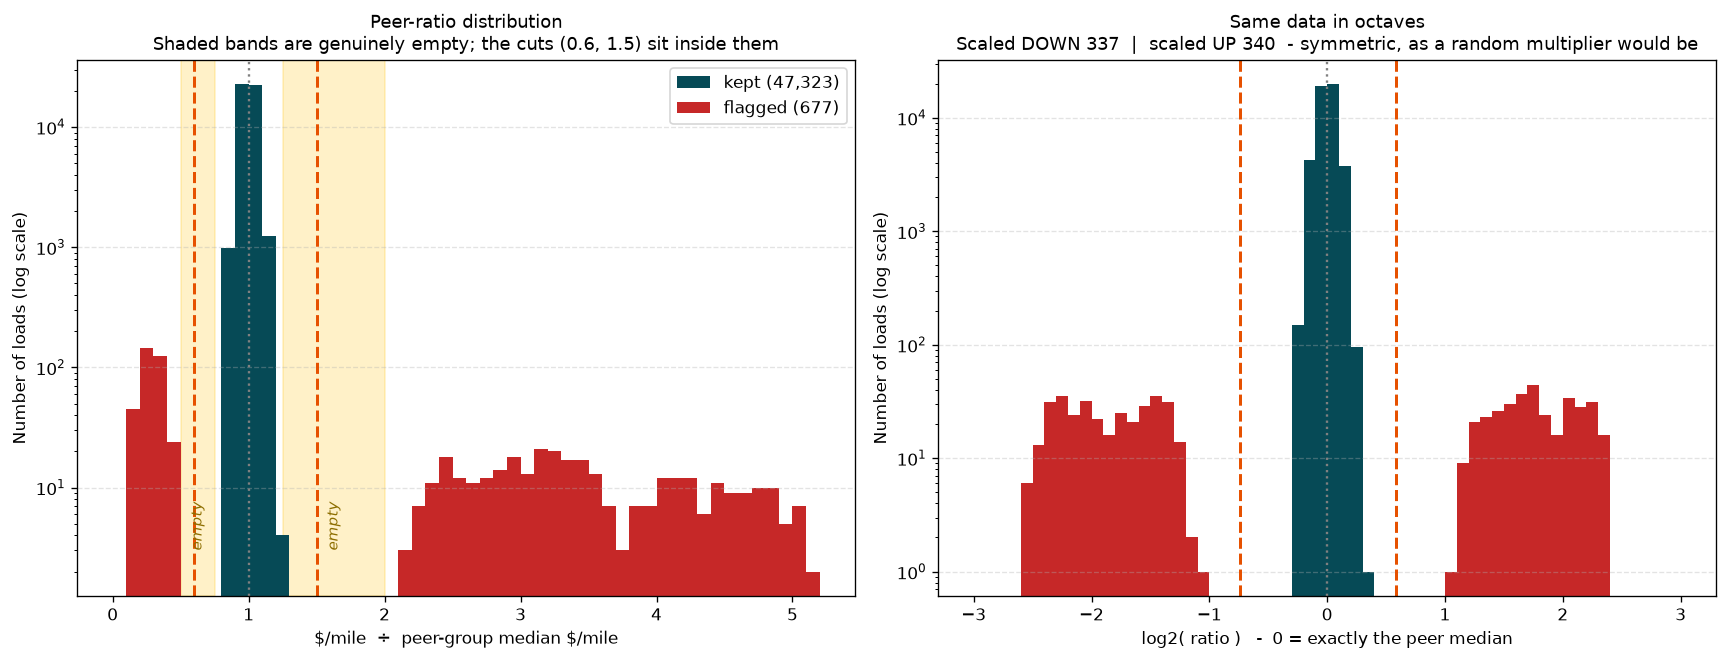

Median distance of a flagged row from its peers: 1.78 octaves (3.4x).
A heavy tail would crowd just outside the cut and thin out gradually.
These sit one to two octaves out, on BOTH sides, with clean air between.


In [7]:
train_df['rate_per_mile'] = train_df['posted_rate'] / train_df['distance']
_bucket = pd.qcut(train_df['distance'], 20, labels=False, duplicates='drop')
_peer = train_df.groupby([_bucket, train_df['equipment']])['rate_per_mile'].median()
_idx = pd.MultiIndex.from_arrays([_bucket, train_df['equipment']])
train_df['peer_ratio'] = train_df['rate_per_mile'] / _peer.reindex(_idx).to_numpy()

hist, edges = np.histogram(train_df['peer_ratio'], bins=np.arange(0, 5.25, 0.25))
print('Distribution of $/mile relative to peer-group median:\n')
for h, lo in zip(hist, edges):
    bar = '#' * min(60, h // 400)
    flag = '   <-- EMPTY GAP' if h == 0 else ''
    print(f'  [{lo:.2f},{lo+0.25:.2f})  {h:6d} {bar}{flag}')

is_corrupt = ~train_df['peer_ratio'].between(0.6, 1.5)
print(f'\nFlagged {is_corrupt.sum()} rows ({is_corrupt.mean():.2%})')
print(f'Rows in [0.50,0.75): {int(((train_df.peer_ratio>=.5)&(train_df.peer_ratio<.75)).sum())}')
print(f'Rows in [1.25,2.00): {int(((train_df.peer_ratio>=1.25)&(train_df.peer_ratio<2)).sum())}')
print('\nThe distribution is BIMODAL with genuinely empty gaps, so this is')
print('injected corruption, not a heavy tail -- the cut point is insensitive')
print('anywhere inside the gap.')

print(f'\nSpread evenly across months (~{int(is_corrupt.groupby(train_df.date.dt.to_period("M")).sum().mean())}/month), confirming injection:')
print(is_corrupt.groupby(train_df['date'].dt.to_period('M')).sum().to_string())

print(f'\nEffect on the summary statistics from Step 2:')
print(f'  posted_rate max  : {train_df.posted_rate.max():>10,.0f} -> {train_df.posted_rate[~is_corrupt].max():>10,.0f}')
print(f'  posted_rate min  : {train_df.posted_rate.min():>10,.2f} -> {train_df.posted_rate[~is_corrupt].min():>10,.2f}')
print(f'  skewness         : {train_df.posted_rate.skew():>10.3f} -> {train_df.posted_rate[~is_corrupt].skew():>10.3f}')
print(f'  corr w/ distance : {train_df.distance.corr(train_df.posted_rate):>10.4f} -> {train_df[~is_corrupt].distance.corr(train_df[~is_corrupt].posted_rate):>10.4f}')

print('\nACTION: drop these from TRAINING ONLY -- never from anything scored,')
print('since the grader scores all 12,000 validation rows. Worth 0.86pp of MAPE.')
print('They also put a ~2.5pp FLOOR under all-row MAPE that no model can cross:')
print('the multiplier is unrelated to any feature, so a perfect model still')
print('books 70-200% error on each. Report all-row AND clean MAPE separately.')


fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.6), dpi=120)

# Panel A -- the ratio itself
ax = axes[0]
bins = np.arange(0, 5.3, 0.1)
ax.hist(train_df.loc[~is_corrupt, 'peer_ratio'], bins=bins, color='#064A56',
        label=f'kept ({int((~is_corrupt).sum()):,})')
ax.hist(train_df.loc[is_corrupt, 'peer_ratio'], bins=bins, color='#C62828',
        label=f'flagged ({int(is_corrupt.sum())})')
ax.set_yscale('log')

for lo, hi in [(0.50, 0.75), (1.25, 2.00)]:          # the empty corridors
    ax.axvspan(lo, hi, color='#FFC107', alpha=0.22, zorder=0)
    ax.text((lo + hi) / 2, 3.0, 'empty', ha='center', va='bottom',
            fontsize=9, style='italic', color='#8D6E00', rotation=90)
for cut in (0.6, 1.5):                                # the cut points
    ax.axvline(cut, color='#E65100', linestyle='--', linewidth=1.8)
ax.axvline(1.0, color='gray', linestyle=':', linewidth=1.4)

ax.set_xlabel(r'\$/mile  $\div$  peer-group median \$/mile')
ax.set_ylabel('Number of loads (log scale)')
ax.set_title('Peer-ratio distribution\nShaded bands are genuinely empty; '
             'the cuts (0.6, 1.5) sit inside them', fontsize=11)
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.35, axis='y')

# Panel B -- the same data in octaves, where the symmetry shows
ax = axes[1]
_oct = np.log2(train_df['peer_ratio'].replace(0, np.nan)).dropna()
_flag = is_corrupt.reindex(_oct.index, fill_value=False)
oct_bins = np.arange(-3, 3.1, 0.1)
ax.hist(_oct[~_flag], bins=oct_bins, color='#064A56')
ax.hist(_oct[_flag], bins=oct_bins, color='#C62828')
ax.set_yscale('log')
ax.axvline(0, color='gray', linestyle=':', linewidth=1.4)
for cut in (np.log2(0.6), np.log2(1.5)):
    ax.axvline(cut, color='#E65100', linestyle='--', linewidth=1.8)

_down = int((train_df.loc[is_corrupt, 'peer_ratio'] < 1).sum())
_up = int((train_df.loc[is_corrupt, 'peer_ratio'] > 1).sum())
ax.set_xlabel('log2( ratio )   -  0 = exactly the peer median')
ax.set_ylabel('Number of loads (log scale)')
ax.set_title(f'Same data in octaves\nScaled DOWN {_down}  |  scaled UP {_up}  '
             '- symmetric, as a random multiplier would be', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.35, axis='y')

plt.tight_layout()
plt.show()

_med_oct = np.median(np.abs(np.log2(train_df.loc[is_corrupt, 'peer_ratio'])))
print(f'Median distance of a flagged row from its peers: {_med_oct:.2f} octaves '
      f'({2 ** _med_oct:.1f}x).')
print('A heavy tail would crowd just outside the cut and thin out gradually.')
print('These sit one to two octaves out, on BOTH sides, with clean air between.')


**Decision.** The distribution is bimodal with **genuinely empty gaps** at
[0.50, 0.75) and [1.50, 2.00), and the 677 flagged

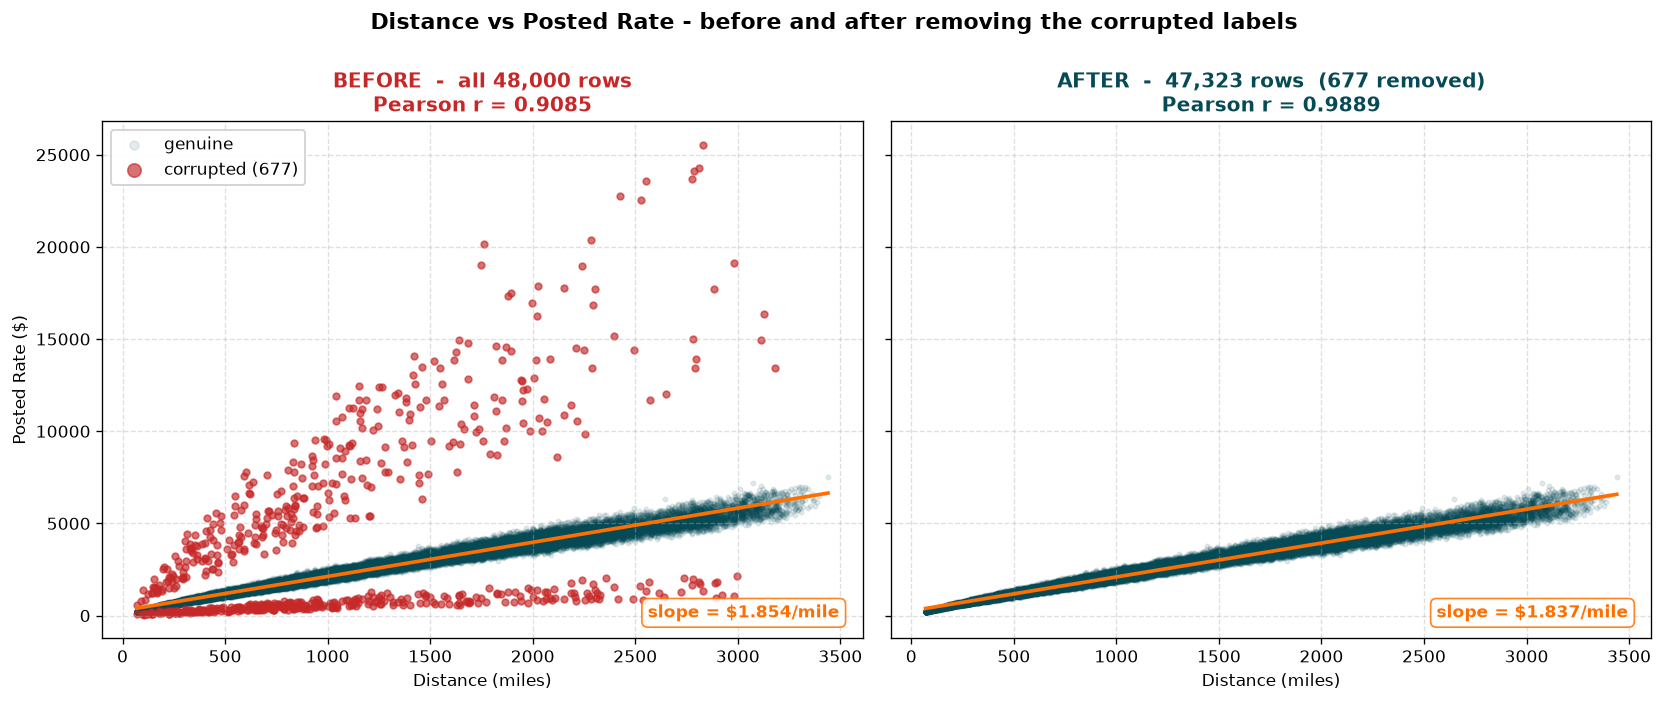

,Before (all rows),After (clean only)
rows,48000.0000,47323.0000
Pearson r,0.9085,0.9889
OLS slope ($/mile),1.8537,1.8370
max rate,25533.0000,7498.0500
min rate,57.2200,184.5500
std dev,1486.4932,1353.6847
skewness,1.9024,0.6882


Removing 677 rows (1.41% of the data) moves
  r      0.9085 -> 0.9889
  slope  $1.854 -> $1.837 per mile
  skew   1.902 -> 0.688


In [8]:
_clean_mask = ~is_corrupt
_d, _y = train_df['distance'], train_df['posted_rate']
_r_all = _d.corr(_y)
_r_clean = _d[_clean_mask].corr(_y[_clean_mask])

# Shared axes on purpose: the whole point is to see what was removed and how
# much vertical range those 677 rows were occupying.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), dpi=120, sharex=True, sharey=True)

for ax, keep_only_clean in zip(axes, (False, True)):
    if keep_only_clean:
        ax.scatter(_d[_clean_mask], _y[_clean_mask], alpha=0.10, s=7, color='#064A56')
        n, r = int(_clean_mask.sum()), _r_clean
        ax.set_title(f'AFTER  -  {n:,} rows  ({int(is_corrupt.sum())} removed)\n'
                     f'Pearson r = {r:.4f}', fontsize=12, fontweight='bold', color='#064A56')
    else:
        ax.scatter(_d[_clean_mask], _y[_clean_mask], alpha=0.10, s=7,
                   color='#064A56', label='genuine')
        ax.scatter(_d[is_corrupt], _y[is_corrupt], alpha=0.65, s=16,
                   color='#C62828', label=f'corrupted ({int(is_corrupt.sum())})')
        n, r = len(train_df), _r_all
        ax.set_title(f'BEFORE  -  all {n:,} rows\nPearson r = {r:.4f}',
                     fontsize=12, fontweight='bold', color='#C62828')
        ax.legend(loc='upper left', framealpha=0.95, markerscale=2)

    # Least-squares line through whatever this panel treats as the data
    mask = _clean_mask if keep_only_clean else slice(None)
    slope, intercept = np.polyfit(_d[mask], _y[mask], 1)
    xs = np.array([_d.min(), _d.max()])
    ax.plot(xs, slope * xs + intercept, color='#FF6F00', linewidth=2.2,
            label=f'fit: ${slope:.2f}/mile')
    ax.text(0.97, 0.04, f'slope = ${slope:.3f}/mile', transform=ax.transAxes,
            ha='right', fontsize=10, fontweight='bold', color='#FF6F00',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85,
                      edgecolor='#FF6F00'))
    ax.set_xlabel('Distance (miles)')
    ax.grid(True, linestyle='--', alpha=0.4)

axes[0].set_ylabel('Posted Rate ($)')
fig.suptitle('Distance vs Posted Rate - before and after removing the corrupted labels',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

_s_all = np.polyfit(_d, _y, 1)[0]
_s_clean = np.polyfit(_d[_clean_mask], _y[_clean_mask], 1)[0]
_cmp = pd.DataFrame({
    'Before (all rows)': [len(train_df), _r_all, _s_all, _y.max(), _y.min(), _y.std(), _y.skew()],
    'After (clean only)': [int(_clean_mask.sum()), _r_clean, _s_clean, _y[_clean_mask].max(),
                           _y[_clean_mask].min(), _y[_clean_mask].std(), _y[_clean_mask].skew()],
}, index=['rows', 'Pearson r', 'OLS slope ($/mile)', 'max rate', 'min rate',
          'std dev', 'skewness']).round(4)
display(_cmp)

print(f'Removing {int(is_corrupt.sum())} rows ({is_corrupt.mean():.2%} of the data) moves')
print(f'  r      {_r_all:.4f} -> {_r_clean:.4f}')
print(f'  slope  ${_s_all:.3f} -> ${_s_clean:.3f} per mile')
print(f'  skew   {_y.skew():.3f} -> {_y[_clean_mask].skew():.3f}')


In [ ]:
_clean = train_df[~is_corrupt]
print(f'corr(distance, posted_rate)        = {_clean.distance.corr(_clean.posted_rate):.4f}')

corr(distance, posted_rate)        = 0.9889
corr(log(distance), log(posted_rate)) = 0.9232


Effect of the corrupted labels on every correlation:


,r (all rows),r (clean rows)
distance,0.9085,0.9889
weight_clean,0.0413,0.0446
market_index,0.0342,0.0366
quote_signal,-0.0399,-0.0428
pickup_lat,-0.0909,-0.0961
pickup_lon,-0.2551,-0.2773
delivery_lat,-0.0920,-0.0993
delivery_lon,-0.2571,-0.2822


,distance,weight_clean,market_index,quote_signal,pickup_lat,pickup_lon,delivery_lat,delivery_lon,posted_rate
distance,1.0000,0.0027,-0.0030,-0.0578,-0.0777,-0.2735,-0.0802,-0.2753,0.9889
weight_clean,0.0027,1.0000,0.0028,0.0059,0.0002,0.0038,-0.0041,0.0015,0.0446
market_index,-0.0030,0.0028,1.0000,-0.0668,-0.0024,0.0018,-0.0022,-0.0076,0.0366
quote_signal,-0.0578,0.0059,-0.0668,1.0000,-0.0041,0.0143,-0.0028,0.0110,-0.0428
pickup_lat,-0.0777,0.0002,-0.0024,-0.0041,1.0000,0.5596,-0.0090,-0.0063,-0.0961
pickup_lon,-0.2735,0.0038,0.0018,0.0143,0.5596,1.0000,-0.0095,-0.0127,-0.2773
delivery_lat,-0.0802,-0.0041,-0.0022,-0.0028,-0.0090,-0.0095,1.0000,0.5573,-0.0993
delivery_lon,-0.2753,0.0015,-0.0076,0.0110,-0.0063,-0.0127,0.5573,1.0000,-0.2822
posted_rate,0.9889,0.0446,0.0366,-0.0428,-0.0961,-0.2773,-0.0993,-0.2822,1.0000


,Pearson r with posted_rate
distance,0.9889
weight_clean,0.0446
market_index,0.0366
quote_signal,-0.0428
pickup_lat,-0.0961
delivery_lat,-0.0993
pickup_lon,-0.2773
delivery_lon,-0.2822


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


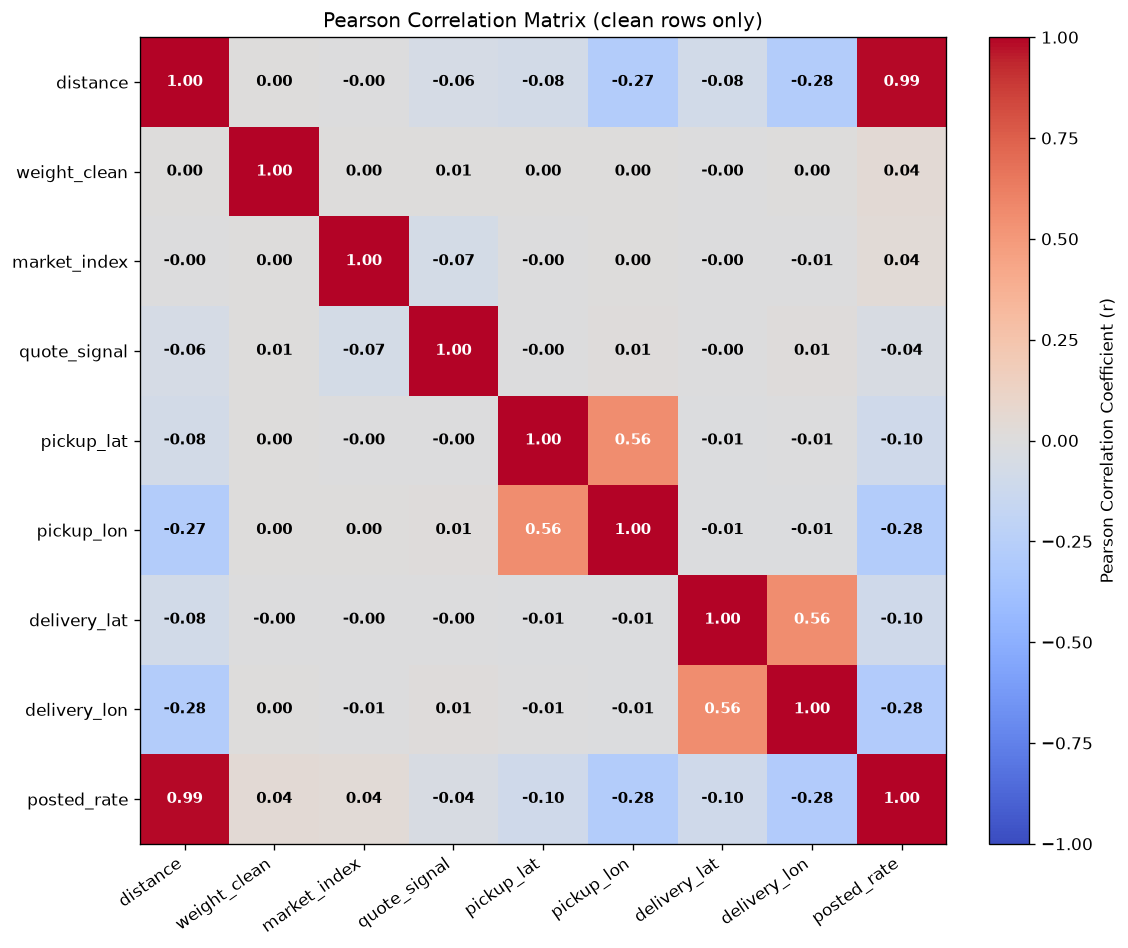

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Select continuous numerical features (using cleaned weight)
corr_cols = [
    'distance', 'weight_clean', 'market_index', 'quote_signal',
    'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'posted_rate'
]

# 2. Calculate Pearson Correlation Matrix (-1.0 to +1.0)
# measure on clean rows
corr_matrix = train_df.loc[~is_corrupt, corr_cols].corr(method='pearson')
_raw = train_df[corr_cols].corr(method='pearson')['posted_rate'].drop('posted_rate')
_cmp = pd.DataFrame({'r (all rows)': _raw.round(4),
                     'r (clean rows)': corr_matrix['posted_rate'].drop('posted_rate').round(4)})
print('Effect of the corrupted labels on every correlation:')
display(_cmp)
display(corr_matrix.round(4))

# 3. Ranked correlation with target variable ('posted_rate')
target_corr = corr_matrix['posted_rate'].drop('posted_rate').sort_values(ascending=False)
display(target_corr.to_frame('Pearson r with posted_rate').round(4))

# 4. Plot Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8), dpi=120)
cax = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
cbar = fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson Correlation Coefficient (r)', fontsize=10)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=35, ha='right', fontsize=10)
ax.set_yticklabels(corr_cols, fontsize=10)

# Annotate each cell with its 2-decimal correlation coefficient
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.iloc[i, j]
        text_color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=9, fontweight='semibold', color=text_color)

plt.title('Pearson Correlation Matrix (clean rows only)')
plt.tight_layout()
plt.show()


In [11]:
# 1. Compare Pearson vs Spearman for Numerical Features (using pure pandas rank correlation)
clean_df = train_df[~is_corrupt]          # <-- the only change
check_cols = ['distance', 'weight_clean', 'market_index', 'quote_signal']
non_lin_rows = []
for c in check_cols:
    p = clean_df[c].corr(clean_df['posted_rate'])
    # Spearman rank correlation is the Pearson correlation of the ranks
    s = clean_df[c].rank().corr(clean_df['posted_rate'].rank())
    diff = abs(s - p)
    diagnosis = 'Likely Non-Linear / Tapered' if diff > 0.05 else 'Linear or Low Linear Signal'
    non_lin_rows.append({
        'Feature': c,
        'Pearson (r)': round(p, 4),
        'Spearman (rho)': round(s, 4),
        '|Diff|': round(diff, 4),
        'Diagnosis': diagnosis
    })
display(pd.DataFrame(non_lin_rows))


,Feature,Pearson (r),Spearman (rho),|Diff|,Diagnosis
0,distance,0.9889,0.9929,0.0040,Linear or Low Linear Signal
1,weight_clean,0.0446,0.0420,0.0026,Linear or Low Linear Signal
2,market_index,0.0366,0.0321,0.0045,Linear or Low Linear Signal
3,quote_signal,-0.0428,-0.0404,0.0024,Linear or Low Linear Signal


In [12]:
for col in cat_cols:
    n_unique = train_df[col].nunique(dropna=False)
    has_nulls = train_df[col].isna().sum()
    print(f"Total Unique Values (Cardinality): {n_unique} | Missing Count: {has_nulls}")
    
    # Frequency table
    val_counts = train_df[col].value_counts(dropna=False)
    val_pcts = train_df[col].value_counts(dropna=False, normalize=True) * 100
    freq_table = pd.DataFrame({
        "Count": val_counts,
        "Percentage (%)": val_pcts.map("{:.2f}%".format)
    })

    if n_unique <= 10:
        print("\nAll Categories & Frequencies:")
        print(freq_table.to_string())
    else:
        print(f"\nTop 10 most frequent categories (out of {n_unique}):")
        print(freq_table.head(10).to_string())
        print("\nComplete list of all unique categories:")
        all_cats = sorted([str(x) for x in train_df[col].dropna().unique()])
        # Format nicely in wrapped lines
        line = "  "
        for item in all_cats:
            if len(line) + len(item) + 2 > 80:
                print(line)
                line = "  " + item + ", "
            else:
                line += item + ", "
        if line.strip():
            print(line.rstrip(", "))

Total Unique Values (Cardinality): 3 | Missing Count: 0

All Categories & Frequencies:
           Count Percentage (%)
equipment                      
Dry Van    27202         56.67%
Reefer     12045         25.09%
Flatbed     8753         18.24%
Total Unique Values (Cardinality): 64 | Missing Count: 0

Top 10 most frequent categories (out of 64):
               Count Percentage (%)
pickup                             
Oklahoma City   1242          2.59%
Lexington       1209          2.52%
Bakersfield     1193          2.49%
Fort Wayne      1170          2.44%
Hartford        1150          2.40%
Richmond        1140          2.38%
Nashville       1124          2.34%
Phoenix         1121          2.34%
Baton Rouge     1115          2.32%
Mobile          1094          2.28%

Complete list of all unique categories:
  Albany, Albuquerque, Amarillo, Atlanta, Austin, Bakersfield, Baltimore, 
  Baton Rouge, Birmingham, Boston, Buffalo, Charleston, Chattanooga, 
  Cincinnati, Columbia, Corpus C

In [13]:
_tc = set(train_df['pickup']) | set(train_df['delivery'])
_vc = set(val_df['pickup']) | set(val_df['delivery'])
_unseen = sorted(_vc - _tc)
_rows = (~val_df['pickup'].isin(_tc) | ~val_df['delivery'].isin(_tc)).sum()

print(f'Cities in training   : {len(_tc)}')
print(f'Cities in validation : {len(_vc)}')
print(f'\nAppearing ONLY in validation ({len(_unseen)}):')
print(f'  {", ".join(_unseen)}')
print(f'\nGraded rows touching one of them: {_rows:,} of {len(val_df):,} ({_rows/len(val_df):.1%})')

print('\nTheir coordinates are known even though their names were never trained on:')
_look = pd.concat([
    train_df[['pickup', 'pickup_lat', 'pickup_lon']].rename(
        columns={'pickup': 'city', 'pickup_lat': 'lat', 'pickup_lon': 'lon'}),
    val_df[['pickup', 'pickup_lat', 'pickup_lon']].rename(
        columns={'pickup': 'city', 'pickup_lat': 'lat', 'pickup_lon': 'lon'}),
]).drop_duplicates('city').set_index('city')
display(_look.loc[_unseen].round(3))

Cities in training   : 64
Cities in validation : 72

Appearing ONLY in validation (8):
  Allentown, Charlotte, Chicago, Jackson, Knoxville, Laredo, Norfolk, San Diego

Graded rows touching one of them: 1,447 of 12,000 (12.1%)

Their coordinates are known even though their names were never trained on:


,lat,lon
city,,
Allentown,40.017,-73.809
Charlotte,34.653,-81.472
Chicago,40.512,-86.867
Jackson,32.078,-90.926
Knoxville,36.257,-86.025
Laredo,25.500,-97.227
Norfolk,37.123,-75.871
San Diego,32.009,-116.896


**Decision.** Do **not** encode `pickup`, `delivery`  as
categorical identity.

In [14]:
_within = train_df.groupby('date')['market_index'].std().mean()
_overall = train_df['market_index'].std()
print(f'within-day sd  {_within:.4f}')
print(f'overall sd     {_overall:.4f}')
print(f'variance explained by date alone: {1 - _within**2 / train_df.market_index.var():.2%}')

within-day sd  0.0249
overall sd     0.1681
variance explained by date alone: 97.80%


**Decision.**  We can impute `market index` from a daily calendar